# Reward Design Function - estándar desde carpetas de simulación

Este notebook está pensado como soporte estándar para auditar y sintonizar funciones de recompensa
desde una carpeta de simulación ya ejecutada.

La organización busca que sea reutilizable en sistemas dinámicos futuros:

1. Primero se carga una corrida y se descubre automáticamente, desde metadata y datos reales, qué variables,
   columnas y componentes de reward están disponibles.
2. Después, cada sección comienza con una caja de configuración que deja explícito qué variables y señales
   alimentan ese análisis.
3. Finalmente, cada salida gráfica se acompaña con texto explicativo e instruccional orientado a la toma de
   decisiones de tuning.


In [36]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj): print(obj)
    def Markdown(text): return text

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

RUNS_ROOT = ROOT / "results_history_CartPole" / "cart_pole"
AVAILABLE_RUNS = sorted([p.name for p in RUNS_ROOT.iterdir() if p.is_dir()]) if RUNS_ROOT.exists() else []

RUN_FOLDER_NAME = "20260326_0052"
EPISODE_SELECTION_MODE = "stabilization_success_best_reward"  # manual | last | best_performance | stabilization_success_best_reward
MANUAL_EPISODE_ID = None

ROLLING_WINDOW = 15
BEHAVIOR_BINS = 12

CROSS_PROFILE_EPISODE_SCOPE = "best_stabilization_success_top_k"  # selected_episode | selected_plus_neighbors | best_stabilization_success_top_k | best_total_reward_top_k
CROSS_PROFILE_TOP_K = 12
CROSS_PROFILE_X_BINS = 60
CROSS_PROFILE_MIN_CURVE_POINTS = 80

VARIABLE_COLUMN_OVERRIDES = {}  # Ejemplo: {"pendulum_angle": {"raw_state_col": "theta_raw", "error_col": "error_theta"}}
SECTION_TARGET_OVERRIDES = {
    "theoretical_surfaces": None,
    "theoretical_profiles": None,
    "interval_curves": None,
    "cross_profiles": None,
    "empirical_profiles": None,
    "step_density_maps": None,
    "interval_behavior_maps": None,
}

CROSS_PROFILE_MANUAL_SPECS = None  # Ejemplo: [{"target_var": "pendulum_angle", "slice_var": "cart_position"}]
CROSS_PROFILE_SLICE_VALUES = {}  # Ejemplo: {"error_cart_position": [-0.1, -0.05, 0.0]}

def choose_episode_id(summary_df, mode, manual_id=None):
    if mode == "manual":
        if manual_id is None:
            raise ValueError("Define MANUAL_EPISODE_ID si usas mode='manual'.")
        return int(manual_id)
    if mode == "last":
        return int(summary_df["episode_id"].max())
    if mode == "best_performance":
        return int(summary_df.sort_values("performance", ascending=False).iloc[0]["episode_id"])
    if mode == "stabilization_success_best_reward":
        mask = summary_df["end_termination_reason"] == "stabilization_success"
        if mask.any():
            return int(summary_df.loc[mask].sort_values("total_reward", ascending=False).iloc[0]["episode_id"])
    return int(summary_df.sort_values("total_reward", ascending=False).iloc[0]["episode_id"])

def infer_chunk_span(summary_df, chunk_files):
    return max(1, int(np.ceil((int(summary_df["episode_id"].max()) + 1) / len(chunk_files))))

def load_episode_by_id(run_dir, episode_id, summary_df):
    chunk_files = sorted(run_dir.glob("episodes_chunks_*.json"))
    if not chunk_files:
        raise FileNotFoundError("No hay episodes_chunks_*.json en la corrida seleccionada.")
    chunk_span = infer_chunk_span(summary_df, chunk_files)
    preferred_idx = episode_id // chunk_span
    ordered = [chunk_files[preferred_idx]] + [p for i, p in enumerate(chunk_files) if i != preferred_idx] if preferred_idx < len(chunk_files) else chunk_files
    for chunk_path in ordered:
        with chunk_path.open("r", encoding="utf-8") as f:
            chunk = json.load(f)
        for episode in chunk:
            if int(episode["episode_id"]) == int(episode_id):
                return episode
    raise KeyError(f"No se encontró episode_id={episode_id}.")

RUN_DIR = RUNS_ROOT / RUN_FOLDER_NAME
if not RUN_DIR.exists():
    raise FileNotFoundError(f"No existe la corrida: {RUN_DIR}")

with (RUN_DIR / "metadata.json").open("r", encoding="utf-8") as f:
    run_metadata = json.load(f)

config_main = run_metadata["config_main"]
reward_base_cfg = config_main["reward_base"]
reward_cfg = reward_base_cfg["reward_config"]
reward_calc_cfg = reward_base_cfg["reward_calculation"]
principal_cfg = reward_calc_cfg["principal_reward"]
extra_cfg = reward_calc_cfg["extra_rewards"]
normalization_cfg = reward_calc_cfg["metric_processing"]["normalization"]
controller_cfg_by_var = {
    cfg["params"]["name_objective_var"]: cfg
    for cfg in config_main["controller_base"]["controllers"].values()
}

summary_df = pd.read_excel(RUN_DIR / "summary.xlsx")
selected_episode_id = choose_episode_id(summary_df, EPISODE_SELECTION_MODE, MANUAL_EPISODE_ID)
selected_episode = load_episode_by_id(RUN_DIR, selected_episode_id, summary_df)

step_df = pd.DataFrame(selected_episode["step_data"]).drop(columns=["n_step"], errors="ignore")
interval_df = pd.DataFrame(selected_episode["interval_data"]).drop(columns=["n_interval"], errors="ignore")

active_var_objs = [cfg["params"]["name_objective_var"] for cfg in config_main["controller_base"]["controllers"].values()]
principal_features = principal_cfg["lineal_combination_params"]["features"] if principal_cfg["method"] == "lineal_combination" else principal_cfg["weighted_exponential_params"]["features"]
band_cfg = extra_cfg["bonus_approach"]["bandwidth_bonus"]
dyn_pen_cfg = extra_cfg["conditional_approach"]["dynamic_penalty"]
decision_steps = int(config_main["simulation"]["decision_interval_sec"] / config_main["simulation"]["dt_sec"])


In [37]:
def show_note(title, bullets):
    bullet_text = "\n".join([f"- {b}" for b in bullets])
    display(Markdown(f"**{title}**\n\n{bullet_text}"))

def show_section_box(title, box_df):
    display(Markdown(f"**Caja de configuración — {title}**"))
    display(box_df.reset_index(drop=True))

def pretty_range(values):
    lo, hi = values
    return f"[{lo:.4f}, {hi:.4f}]"

def compact_value(value):
    if value is None:
        return "auto"
    if isinstance(value, str):
        return value
    if isinstance(value, (list, tuple)):
        return ", ".join(str(v) for v in value)
    if isinstance(value, dict):
        return json.dumps(value, ensure_ascii=False)
    return str(value)

def require_items(items, section_name):
    if not items:
        raise ValueError(f"La sección '{section_name}' no tiene variables o especificaciones activas. Revisa SECTION_TARGET_OVERRIDES o CROSS_PROFILE_MANUAL_SPECS.")

def choose_first_existing(candidates, columns):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None

def metric_range_abs(var_obj, feature_keys, fallback=1.0):
    params = normalization_cfg["params"].get(var_obj, {})
    for feature_key in feature_keys:
        if feature_key in params:
            lo, hi = params[feature_key]["range"]
            return max(abs(lo), abs(hi))
    return fallback

def observed_max(series, fallback, floor=1e-3):
    if series is None or len(series) == 0:
        return fallback
    q = float(np.nanquantile(np.abs(series), 0.99))
    return min(fallback, max(floor, 1.25 * q)) if np.isfinite(q) and q > 0 else fallback

def raw_state_range(var_obj):
    return config_main["dynamic_system"]["state_normalization"]["ranges_params"][var_obj]

def stabilization_band_raw(var_obj):
    criteria = config_main["dynamic_system"]["termination_conditions"]["stabilization_criteria"]
    return criteria[var_obj] if var_obj in criteria else raw_state_range(var_obj)

def band_range(var_obj):
    return band_cfg["ranges"].get(f"error_{var_obj}", stabilization_band_raw(var_obj))

def reward_columns_for_var(df, var_obj):
    return sorted(c for c in df.columns if c.startswith("reward_") and c.endswith(var_obj))

def extra_columns_for_var(df, var_obj):
    return sorted(c for c in df.columns if c.startswith("extra_") and c.endswith(var_obj))

def reward_assignment_mode(local_interval_df, var_obj, reward_cols=None):
    reward_cols = reward_columns_for_var(local_interval_df, var_obj) if reward_cols is None else list(reward_cols)
    if not reward_cols:
        return "no_reward_columns"
    reward_block = local_interval_df[reward_cols]
    distinct_per_row = reward_block.nunique(axis=1, dropna=False)
    if len(reward_cols) == 1 or int(distinct_per_row.max()) <= 1:
        return "representative_first_reward_column"
    return "mean_over_reward_columns"

def assigned_reward_series(local_interval_df, var_obj):
    reward_cols = reward_columns_for_var(local_interval_df, var_obj)
    if not reward_cols:
        return pd.Series(np.nan, index=local_interval_df.index)
    reward_block = local_interval_df[reward_cols]
    distinct_per_row = reward_block.nunique(axis=1, dropna=False)
    if len(reward_cols) == 1 or int(distinct_per_row.max()) <= 1:
        return reward_block.iloc[:, 0]
    return reward_block.mean(axis=1)

def normalize_constant(var_obj, feature_key, level):
    params = normalization_cfg["params"].get(var_obj, {})
    cfg = params.get(feature_key)
    arr = np.asarray(level, dtype=float)
    if cfg is None:
        return np.zeros_like(arr)
    lo, hi = cfg["range"]
    out_lo, out_hi = normalization_cfg["output_limits"]
    arr_abs = np.abs(arr)
    if cfg["method"] == "mean_squared":
        span = max(abs(lo), abs(hi)) ** 2
        z = np.square(arr_abs) / span if span > 0 else np.zeros_like(arr)
    elif cfg["method"] in {"abs", "rms"}:
        span = max(abs(lo), abs(hi))
        z = arr_abs / span if span > 0 else np.zeros_like(arr)
    else:
        span = hi - lo if hi != lo else 1.0
        z = np.abs(arr - lo) / span
    z = np.clip(z, 0.0, 1.0)
    return out_lo + z * (out_hi - out_lo)

def principal_loop_reward(var_obj, error_level, edot_level, I_level=0.0, delta_u_eff_level=0.0):
    vals = {
        "L_e": normalize_constant(var_obj, "e", error_level),
        "L_edot": normalize_constant(var_obj, "edot", edot_level),
        "L_I": normalize_constant(var_obj, "I", I_level),
        "L_delta_u": normalize_constant(var_obj, "delta_u", delta_u_eff_level),
    }
    if principal_cfg["method"] == "lineal_combination":
        return sum(-principal_features[k]["weight"] * v for k, v in vals.items())
    total = np.zeros_like(np.asarray(vals["L_e"], dtype=float))
    for k, v in vals.items():
        p = principal_features[k]
        total -= p["weight"] * (1.0 - np.exp(-p["scaled"] * (v - p.get("setpoint", 0.0)) ** 2))
    return total

def band_bonus(var_obj, error_level):
    lo, hi = band_range(var_obj)
    limit = max(abs(lo), abs(hi))
    raw = np.where(np.abs(np.asarray(error_level, dtype=float)) <= limit, decision_steps * band_cfg["per_step_band_bonus"], 0.0)
    return np.minimum(raw, band_cfg["max_total_band_bonus"][var_obj])

def dyn_penalty(var_obj, control_level, error_level):
    if not dyn_pen_cfg["enabled"]:
        return np.zeros_like(np.asarray(control_level, dtype=float))
    cfg = dyn_pen_cfg["dynamic_penalty_params"].get(f"control_action_{var_obj}")
    if cfg is None:
        return np.zeros_like(np.asarray(control_level, dtype=float))
    control_abs = np.abs(np.asarray(control_level, dtype=float))
    error_abs = np.abs(np.asarray(error_level, dtype=float))
    cond = cfg["condition"]
    factor = np.exp(-cond.get("scaled", 1.0) * (error_abs - cond.get("setpoint", 0.0)) ** 2)
    if dyn_pen_cfg["method"] == "quadratic":
        return -cfg["weight"] * (control_abs ** 2) * factor
    return -cfg["weight"] * control_abs * factor

def total_proxy(var_obj, error_level, control_level, edot_level=0.0):
    return principal_loop_reward(var_obj, error_level, edot_level) + band_bonus(var_obj, error_level) + dyn_penalty(var_obj, control_level, error_level)

def infer_variable_catalog(active_vars, step_frame, interval_frame):
    catalog = {}
    for var_obj in active_vars:
        override = VARIABLE_COLUMN_OVERRIDES.get(var_obj, {})
        reward_cols = override.get("reward_cols", reward_columns_for_var(interval_frame, var_obj))
        extra_cols = override.get("extra_cols", extra_columns_for_var(interval_frame, var_obj))
        catalog[var_obj] = {
            "var_obj": var_obj,
            "raw_state_col": override.get("raw_state_col", choose_first_existing([f"{var_obj}_raw", var_obj], step_frame.columns)),
            "error_col": override.get("error_col", choose_first_existing([f"error_{var_obj}"], step_frame.columns)),
            "derivative_error_col": override.get("derivative_error_col", choose_first_existing([f"derivative_error_{var_obj}", f"delta_error_{var_obj}"], step_frame.columns)),
            "integral_error_col": override.get("integral_error_col", choose_first_existing([f"integral_error_{var_obj}"], step_frame.columns)),
            "control_action_col": override.get("control_action_col", choose_first_existing([f"control_action_{var_obj}", f"u_eff_{var_obj}", "u_total"], step_frame.columns)),
            "delta_u_col": override.get("delta_u_col", choose_first_existing([f"delta_u_eff_{var_obj}", f"delta_control_action_{var_obj}", "delta_u_total"], step_frame.columns)),
            "reward_cols": reward_cols,
            "extra_cols": extra_cols,
            "band_range_raw": band_range(var_obj),
            "stabilization_band_raw": stabilization_band_raw(var_obj),
            "reward_assignment_mode": reward_assignment_mode(interval_frame, var_obj, reward_cols=reward_cols),
            "column_source": "manual_override" if override else "auto_from_metadata_and_columns",
        }
    return catalog

def variable_catalog_view(variable_catalog):
    rows = []
    for var_obj, meta in variable_catalog.items():
        rows.append({
            "var_obj": var_obj,
            "raw_state_col": meta["raw_state_col"],
            "error_col": meta["error_col"],
            "derivative_error_col": meta["derivative_error_col"],
            "control_action_col": meta["control_action_col"],
            "delta_u_col": meta["delta_u_col"],
            "reward_cols": ", ".join(meta["reward_cols"]) if meta["reward_cols"] else "-",
            "extra_cols": ", ".join(meta["extra_cols"]) if meta["extra_cols"] else "-",
            "band_range_raw": pretty_range(meta["band_range_raw"]),
            "stabilization_band_raw": pretty_range(meta["stabilization_band_raw"]),
            "reward_assignment_mode": meta["reward_assignment_mode"],
            "column_source": meta["column_source"],
        })
    return pd.DataFrame(rows)


In [38]:
def vars_for_section(section_name, discovered_vars):
    override = SECTION_TARGET_OVERRIDES.get(section_name)
    if override is None:
        return list(discovered_vars)
    return [var for var in override if var in discovered_vars]

def default_axis_label(var_obj):
    if "angle" in var_obj:
        return r"$\theta_{val}\ [rad]$"
    if "position" in var_obj:
        return r"$x_{val}\ [m]$"
    return var_obj

def default_slice_label(var_obj):
    if var_obj == "pendulum_angle":
        return "e_theta"
    if var_obj == "cart_position":
        return "e_x"
    return f"e_{var_obj}"

def normalize_cross_profile_spec(spec, variable_catalog):
    target_var = spec["target_var"]
    if target_var not in variable_catalog:
        raise KeyError(f"target_var '{target_var}' no existe en la metadata descubierta.")
    target_meta = variable_catalog[target_var]

    slice_var = spec.get("slice_var")
    slice_col = spec.get("slice_col")
    if slice_col is None:
        if slice_var is None:
            other_vars = [v for v in variable_catalog if v != target_var]
            slice_var = other_vars[0] if other_vars else target_var
        if slice_var not in variable_catalog:
            raise KeyError(f"slice_var '{slice_var}' no existe en la metadata descubierta.")
        slice_col = variable_catalog[slice_var]["error_col"]
    elif slice_var is None and str(slice_col).startswith("error_"):
        slice_var = str(slice_col).replace("error_", "")

    return {
        "target_var": target_var,
        "x_col": spec.get("x_col", target_meta["raw_state_col"]),
        "slice_var": slice_var,
        "slice_col": slice_col,
        "reward_col": spec.get("reward_col", "global_reward_per_step"),
        "slice_label": spec.get("slice_label", default_slice_label(slice_var) if slice_var else compact_value(slice_col)),
        "x_label": spec.get("x_label", default_axis_label(target_var)),
        "title": spec.get("title", f"Total Reward Profiles — {target_var}"),
        "slice_values": spec.get("slice_values", CROSS_PROFILE_SLICE_VALUES.get(slice_col)),
    }

def infer_cross_profile_specs(variable_catalog):
    target_vars = vars_for_section("cross_profiles", list(variable_catalog))
    if CROSS_PROFILE_MANUAL_SPECS is not None:
        return [normalize_cross_profile_spec(spec, variable_catalog) for spec in CROSS_PROFILE_MANUAL_SPECS]

    specs = []
    for idx, target_var in enumerate(target_vars):
        other_vars = [v for v in target_vars if v != target_var]
        slice_var = other_vars[idx % len(other_vars)] if other_vars else target_var
        spec = normalize_cross_profile_spec({
            "target_var": target_var,
            "slice_var": slice_var,
        }, variable_catalog)
        if spec["x_col"] and spec["slice_col"]:
            specs.append(spec)
    return specs

def build_section_config(variable_catalog):
    discovered_vars = list(variable_catalog)
    section_config = {}

    surface_vars = vars_for_section("theoretical_surfaces", discovered_vars)
    section_config["theoretical_surfaces"] = {
        "target_vars": surface_vars,
        "data_source": "metadata + selected_episode",
        "box_df": pd.DataFrame([
            {
                "parameter_source": "metadata + SECTION_TARGET_OVERRIDES",
                "data_source": "metadata + rangos observados del episodio",
                "var_obj": var_obj,
                "x_axis": variable_catalog[var_obj]["error_col"],
                "y_axis": variable_catalog[var_obj]["derivative_error_col"],
                "proxy_control_axis": variable_catalog[var_obj]["control_action_col"],
                "band_range_raw": pretty_range(variable_catalog[var_obj]["band_range_raw"]),
                "stabilization_band_raw": pretty_range(variable_catalog[var_obj]["stabilization_band_raw"]),
            }
            for var_obj in surface_vars
        ]),
    }

    profile_vars = vars_for_section("theoretical_profiles", discovered_vars)
    section_config["theoretical_profiles"] = {
        "target_vars": profile_vars,
        "data_source": "metadata + selected_episode",
        "box_df": pd.DataFrame([
            {
                "parameter_source": "metadata + SECTION_TARGET_OVERRIDES",
                "data_source": "metadata + rangos observados del episodio",
                "var_obj": var_obj,
                "x_error_col": variable_catalog[var_obj]["error_col"],
                "x_control_col": variable_catalog[var_obj]["control_action_col"],
                "error_profile_rule": "0, 0.5*band, 1.0*band, min(observed_max, 2*band)",
                "control_profile_rule": "0, 15%, 35%, 65% del max observado",
                "band_range_raw": pretty_range(variable_catalog[var_obj]["band_range_raw"]),
            }
            for var_obj in profile_vars
        ]),
    }

    interval_vars = vars_for_section("interval_curves", discovered_vars)
    section_config["interval_curves"] = {
        "target_vars": interval_vars,
        "data_source": "selected_episode",
        "box_df": pd.DataFrame([
            {
                "parameter_source": "metadata + SECTION_TARGET_OVERRIDES",
                "data_source": "episodio seleccionado",
                "var_obj": var_obj,
                "interval_axis": "interval_id",
                "principal_col": f"principal_loop_{var_obj}",
                "extra_col": f"extra_total_{var_obj}",
                "assigned_reward_col": f"assigned_reward_{var_obj}",
                "rolling_window": ROLLING_WINDOW,
            }
            for var_obj in interval_vars
        ]),
    }

    cross_specs = infer_cross_profile_specs(variable_catalog)
    section_config["cross_profiles"] = {
        "target_vars": [spec["target_var"] for spec in cross_specs],
        "data_source": CROSS_PROFILE_EPISODE_SCOPE,
        "specs": cross_specs,
        "box_df": pd.DataFrame([
            {
                "parameter_source": "metadata + CROSS_PROFILE_MANUAL_SPECS + CROSS_PROFILE_SLICE_VALUES",
                "data_source": CROSS_PROFILE_EPISODE_SCOPE,
                "top_k": CROSS_PROFILE_TOP_K,
                "x_bins": CROSS_PROFILE_X_BINS,
                "min_curve_points": CROSS_PROFILE_MIN_CURVE_POINTS,
                "target_var": spec["target_var"],
                "x_col": spec["x_col"],
                "slice_var": spec["slice_var"],
                "slice_col": spec["slice_col"],
                "slice_label": spec["slice_label"],
                "reward_col": spec["reward_col"],
                "manual_slice_values": compact_value(spec["slice_values"]),
            }
            for spec in cross_specs
        ]),
    }

    empirical_vars = vars_for_section("empirical_profiles", discovered_vars)
    section_config["empirical_profiles"] = {
        "target_vars": empirical_vars,
        "data_source": "selected_episode",
        "box_df": pd.DataFrame([
            {
                "parameter_source": "metadata + SECTION_TARGET_OVERRIDES",
                "data_source": "episodio seleccionado",
                "var_obj": var_obj,
                "x_error_col": f"mean_abs_error_{var_obj}",
                "x_control_col": f"mean_abs_control_action_{var_obj}",
                "principal_col": f"principal_loop_{var_obj}",
                "extra_col": f"extra_total_{var_obj}",
                "assigned_reward_col": f"assigned_reward_{var_obj}",
            }
            for var_obj in empirical_vars
        ]),
    }

    density_vars = vars_for_section("step_density_maps", discovered_vars)
    section_config["step_density_maps"] = {
        "target_vars": density_vars,
        "data_source": "selected_episode",
        "box_df": pd.DataFrame([
            {
                "parameter_source": "metadata + SECTION_TARGET_OVERRIDES",
                "data_source": "step_data del episodio seleccionado",
                "var_obj": var_obj,
                "x_col": variable_catalog[var_obj]["error_col"],
                "y_col": variable_catalog[var_obj]["control_action_col"],
                "highlight_band": pretty_range(variable_catalog[var_obj]["band_range_raw"]),
            }
            for var_obj in density_vars
        ]),
    }

    interval_map_vars = vars_for_section("interval_behavior_maps", discovered_vars)
    section_config["interval_behavior_maps"] = {
        "target_vars": interval_map_vars,
        "data_source": "selected_episode",
        "box_df": pd.DataFrame([
            {
                "parameter_source": "metadata + SECTION_TARGET_OVERRIDES",
                "data_source": "interval_data reconstruido",
                "var_obj": var_obj,
                "x_col": f"mean_abs_error_{var_obj}",
                "y_col": f"mean_abs_control_action_{var_obj}",
                "color_col": f"assigned_reward_{var_obj}",
                "highlight_band": pretty_range(variable_catalog[var_obj]["band_range_raw"]),
            }
            for var_obj in interval_map_vars
        ]),
    }
    return section_config

def build_section_summary_df(section_config):
    rows = []
    for section_name, cfg in section_config.items():
        rows.append({
            "section": section_name,
            "target_vars": ", ".join(cfg["target_vars"]) if cfg["target_vars"] else "-",
            "data_source": cfg["data_source"],
            "editable_from": "VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVERRIDES" if section_name != "cross_profiles" else "VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVERRIDES + CROSS_PROFILE_MANUAL_SPECS",
        })
    return pd.DataFrame(rows)


In [39]:
def build_behavior_df(interval_frame, step_frame, variable_catalog):
    data = interval_frame.copy()
    for var_obj in variable_catalog:
        extra_cols = variable_catalog[var_obj]["extra_cols"]
        data[f"extra_total_{var_obj}"] = data[extra_cols].sum(axis=1) if extra_cols else 0.0
        data[f"assigned_reward_{var_obj}"] = assigned_reward_series(data, var_obj)
        data[f"principal_loop_{var_obj}"] = data[f"assigned_reward_{var_obj}"] - data[f"extra_total_{var_obj}"]

    rows = []
    for _, row in data.iterrows():
        start_idx = int(row["interval_start_step_idx"])
        end_idx = int(row["interval_end_step_idx"])
        step_slice = step_frame.iloc[start_idx:end_idx + 1]
        out_row = row.to_dict()
        for var_obj, meta in variable_catalog.items():
            error_col = meta["error_col"]
            control_col = meta["control_action_col"]
            out_row[f"mean_abs_error_{var_obj}"] = float(step_slice[error_col].abs().mean()) if error_col else np.nan
            out_row[f"mean_abs_control_action_{var_obj}"] = float(step_slice[control_col].abs().mean()) if control_col else np.nan
        rows.append(out_row)

    out = pd.DataFrame(rows)
    out["principal_total_rebuilt"] = out[[f"principal_loop_{var_obj}" for var_obj in variable_catalog]].sum(axis=1)
    out["extras_total_rebuilt"] = out[[f"extra_total_{var_obj}" for var_obj in variable_catalog]].sum(axis=1)
    out["global_reward_rebuilt"] = out["principal_total_rebuilt"] + out["extras_total_rebuilt"]
    return out

def build_step_reward_df_from_episode(episode_data, variable_catalog):
    local_step_df = pd.DataFrame(episode_data["step_data"]).drop(columns=["n_step"], errors="ignore")
    local_interval_df = pd.DataFrame(episode_data["interval_data"]).drop(columns=["n_interval"], errors="ignore")

    local_step_df["global_reward_per_step"] = np.nan
    assigned_interval_rewards = {
        var_obj: assigned_reward_series(local_interval_df, var_obj)
        for var_obj in variable_catalog
    }
    for var_obj in variable_catalog:
        local_step_df[f"assigned_reward_per_step_{var_obj}"] = np.nan

    for row_idx, interval_row in local_interval_df.iterrows():
        start_idx = int(interval_row["interval_start_step_idx"])
        end_idx = int(interval_row["interval_end_step_idx"])
        n_steps = max(1, int(interval_row["interval_n_steps"]))
        local_step_df.loc[start_idx:end_idx, "global_reward_per_step"] = float(interval_row["global_interval_reward"]) / n_steps
        for var_obj in variable_catalog:
            value = float(assigned_interval_rewards[var_obj].iloc[row_idx]) / n_steps
            local_step_df.loc[start_idx:end_idx, f"assigned_reward_per_step_{var_obj}"] = value

    local_step_df["episode_id"] = int(episode_data["episode_id"])
    return local_step_df

def load_episodes_by_ids(run_dir, episode_ids, summary_frame):
    chunk_files = sorted(run_dir.glob("episodes_chunks_*.json"))
    chunk_span = max(1, int(np.ceil((int(summary_frame["episode_id"].max()) + 1) / len(chunk_files))))
    chunk_to_ids = {}
    for ep_id in episode_ids:
        chunk_idx = min(len(chunk_files) - 1, int(ep_id) // chunk_span)
        chunk_to_ids.setdefault(chunk_idx, set()).add(int(ep_id))

    loaded = {}
    for chunk_idx, ids_in_chunk in chunk_to_ids.items():
        with chunk_files[chunk_idx].open("r", encoding="utf-8") as f:
            chunk = json.load(f)
        for episode_data in chunk:
            ep_id = int(episode_data["episode_id"])
            if ep_id in ids_in_chunk:
                loaded[ep_id] = episode_data
    return [loaded[ep_id] for ep_id in episode_ids if ep_id in loaded]

def select_profile_episode_ids(summary_frame, mode, selected_id, top_k):
    if mode == "selected_episode":
        return [int(selected_id)]
    if mode == "selected_plus_neighbors":
        order = summary_frame.sort_values("episode_id").reset_index(drop=True)
        row_idx = int(order.index[order["episode_id"] == selected_id][0])
        lo = max(0, row_idx - top_k // 2)
        hi = min(len(order), row_idx + top_k // 2 + 1)
        return [int(v) for v in order.iloc[lo:hi]["episode_id"].tolist()]
    if mode == "best_total_reward_top_k":
        return [int(v) for v in summary_frame.sort_values("total_reward", ascending=False).head(top_k)["episode_id"].tolist()]
    mask = summary_frame["end_termination_reason"] == "stabilization_success"
    source = summary_frame.loc[mask] if mask.any() else summary_frame
    return [int(v) for v in source.sort_values("total_reward", ascending=False).head(top_k)["episode_id"].tolist()]

def build_cross_profile_df():
    episode_ids = select_profile_episode_ids(
        summary_frame=summary_df,
        mode=CROSS_PROFILE_EPISODE_SCOPE,
        selected_id=selected_episode_id,
        top_k=CROSS_PROFILE_TOP_K,
    )
    episode_list = load_episodes_by_ids(RUN_DIR, episode_ids, summary_df)
    frames = [build_step_reward_df_from_episode(episode, VARIABLE_CATALOG) for episode in episode_list]
    if not frames:
        return build_step_reward_df_from_episode(selected_episode, VARIABLE_CATALOG)
    return pd.concat(frames, ignore_index=True)

def profile(df, x_col, y_cols):
    valid = df[[x_col] + y_cols].dropna()
    bins = pd.cut(valid[x_col], bins=BEHAVIOR_BINS, duplicates="drop")
    grouped = valid.groupby(bins, observed=False)[y_cols].mean()
    mids = [interval.mid for interval in grouped.index]
    grouped.insert(0, x_col, mids)
    return grouped.reset_index(drop=True)

def cross_slice_values(series, manual_values=None, n_levels=5):
    if manual_values is not None:
        return [float(v) for v in manual_values]
    clean = pd.Series(series).dropna().astype(float)
    if clean.empty:
        return [0.0]
    if clean.nunique() == 1:
        return [float(clean.iloc[0])]
    quantiles = np.linspace(0.10, 0.90, min(n_levels, int(clean.nunique())))
    values = np.nanquantile(clean, quantiles)
    scale = max(float(np.nanquantile(np.abs(clean), 0.90)), 1e-3)
    out = []
    for value in np.atleast_1d(values):
        numeric_value = float(value)
        if not any(np.isclose(numeric_value, previous, atol=scale * 0.02, rtol=0.0) for previous in out):
            out.append(numeric_value)
    return out if out else [float(clean.median())]

def plot_cross_reward_profiles(ax, df, x_col, slice_col, reward_col, target_var, slice_label, title, x_label, slice_values=None):
    local = df[[x_col, slice_col, reward_col]].dropna().copy()
    x_low, x_high = np.nanquantile(local[x_col], [0.01, 0.99])
    if not np.isfinite(x_low) or not np.isfinite(x_high) or x_low == x_high:
        x_low, x_high = float(local[x_col].min()), float(local[x_col].max())
    bins = np.linspace(x_low, x_high, CROSS_PROFILE_X_BINS)
    slice_vals = cross_slice_values(local[slice_col], manual_values=slice_values)
    sorted_vals = np.sort(np.unique(np.asarray(slice_vals, dtype=float)))
    data_min = float(local[slice_col].min())
    data_max = float(local[slice_col].max())

    if len(sorted_vals) == 1:
        spread = float(np.nanquantile(np.abs(local[slice_col]), 0.75))
        half_width = max(spread / 4.0, 1e-3)
        slice_windows = [(float(sorted_vals[0]), data_min, data_max, half_width)]
    else:
        midpoints = (sorted_vals[:-1] + sorted_vals[1:]) / 2.0
        slice_windows = []
        for idx, slice_value in enumerate(sorted_vals):
            left = data_min if idx == 0 else float(midpoints[idx - 1])
            right = data_max if idx == len(sorted_vals) - 1 else float(midpoints[idx])
            slice_windows.append((float(slice_value), left, right, None))

    support_rows = []
    for idx, (slice_value, left, right, half_width) in enumerate(slice_windows):
        if half_width is None:
            if idx == len(slice_windows) - 1:
                subset = local[(local[slice_col] >= left) & (local[slice_col] <= right)].copy()
            else:
                subset = local[(local[slice_col] >= left) & (local[slice_col] < right)].copy()
        else:
            subset = local[np.abs(local[slice_col] - slice_value) <= half_width].copy()

        label_value = float(subset[slice_col].median()) if len(subset) else float(slice_value)
        support_rows.append({
            "slice_label": slice_label,
            "slice_value": label_value,
            "slice_low": float(left if half_width is None else slice_value - half_width),
            "slice_high": float(right if half_width is None else slice_value + half_width),
            "n_points": int(len(subset)),
            "x_min": float(subset[x_col].min()) if len(subset) else np.nan,
            "x_max": float(subset[x_col].max()) if len(subset) else np.nan,
        })

        if len(subset) < CROSS_PROFILE_MIN_CURVE_POINTS:
            continue
        grouped_mean = subset.groupby(pd.cut(subset[x_col], bins=bins, include_lowest=True), observed=False)[reward_col].mean()
        grouped_count = subset.groupby(pd.cut(subset[x_col], bins=bins, include_lowest=True), observed=False)[reward_col].count()
        valid = (grouped_count >= 3) & grouped_mean.notna()
        if valid.sum() < 5:
            continue
        centers = np.array([interval.mid for interval in grouped_mean.index[valid]])
        ax.plot(centers, grouped_mean[valid].values, label=f"{slice_label}={label_value:.3f}")

    stab_lo, stab_hi = stabilization_band_raw(target_var)
    ax.axvspan(stab_lo, stab_hi, alpha=0.15, color="lightsteelblue")
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Reward per step")
    ax.legend()
    return pd.DataFrame(support_rows)

overview_df = pd.DataFrame([{
    "run_folder": RUN_FOLDER_NAME,
    "selected_episode_id": selected_episode_id,
    "reward_approach": reward_cfg["reward_approach"],
    "principal_method": principal_cfg["method"],
    "n_intervals": int(interval_df["interval_id"].nunique()),
    "n_steps": int(step_df.shape[0]),
}])

principal_df = pd.DataFrame(principal_features).T.rename_axis("feature").reset_index()
band_df = pd.DataFrame([{
    "var_obj": var_obj,
    "band_min": band_cfg["ranges"][f"error_{var_obj}"][0],
    "band_max": band_cfg["ranges"][f"error_{var_obj}"][1],
    "per_step_band_bonus": band_cfg["per_step_band_bonus"],
    "max_total_band_bonus": band_cfg["max_total_band_bonus"][var_obj],
} for var_obj in active_var_objs])

VARIABLE_CATALOG = infer_variable_catalog(active_var_objs, step_df, interval_df)
VARIABLE_CATALOG_DF = variable_catalog_view(VARIABLE_CATALOG)
SECTION_CONFIG = build_section_config(VARIABLE_CATALOG)
SECTION_SUMMARY_DF = build_section_summary_df(SECTION_CONFIG)

behavior_df = build_behavior_df(interval_df, step_df, VARIABLE_CATALOG)
step_reward_df = build_step_reward_df_from_episode(selected_episode, VARIABLE_CATALOG)
cross_profile_df = build_cross_profile_df()

display(overview_df)
display(principal_df)
display(band_df)
display(VARIABLE_CATALOG_DF)
display(SECTION_SUMMARY_DF)

show_note(
    "Cómo usar la capa estándar del notebook",
    [
        "La primera caja editable del notebook está en esta etapa: aquí eliges la carpeta de simulación y, si hace falta, fuerzas variables objetivo o perfiles cruzados manuales.",
        "Aunque la mayoría de los parámetros se descubren automáticamente desde metadata y columnas disponibles, estas tablas dejan explícito qué señales concretas va a usar cada sección.",
        "Si escalas el sistema a otro dominio, primero puedes corregir el mapeo con `VARIABLE_COLUMN_OVERRIDES`, luego definir variables objetivo con `SECTION_TARGET_OVERRIDES` y finalmente afinar perfiles cruzados con `CROSS_PROFILE_MANUAL_SPECS`.",
        "Las cajas que aparecen al inicio de cada sección reutilizan esta configuración base para que siempre sea visible qué se está analizando y con qué evidencia.",
    ],
)


,run_folder,selected_episode_id,reward_approach,principal_method,n_intervals,n_steps
0,20260326_0052,4673,controller_reward,weighted_exponential,66,1310


,feature,weight,scaled,setpoint
0,L_e,0.45,2.2,0.0
1,L_edot,0.20,1.2,0.0
2,L_I,0.00,1.0,0.0
3,L_delta_u,0.08,0.3,0.0


,var_obj,band_min,band_max,per_step_band_bonus,max_total_band_bonus
0,pendulum_angle,-0.04,0.04,0.02,6.0
1,cart_position,-0.03,0.03,0.02,8.0


,var_obj,raw_state_col,error_col,derivative_error_col,control_action_col,delta_u_col,reward_cols,extra_cols,band_range_raw,stabilization_band_raw,reward_assignment_mode,column_source
0,pendulum_angle,pendulum_angle_raw,error_pendulum_angle,derivative_error_pendulum_angle,control_action_pendulum_angle,delta_u_eff_pendulum_angle,"reward_kd_pendulum_angle, reward_ki_pendulum_a...","extra_bonus_band_pendulum_angle, extra_conditi...","[-0.0400, 0.0400]","[-0.0200, 0.0200]",representative_first_reward_column,auto_from_metadata_and_columns
1,cart_position,cart_position_raw,error_cart_position,derivative_error_cart_position,control_action_cart_position,delta_u_eff_cart_position,"reward_kd_cart_position, reward_ki_cart_positi...","extra_bonus_band_cart_position, extra_conditio...","[-0.0300, 0.0300]","[-0.1000, 0.1000]",representative_first_reward_column,auto_from_metadata_and_columns


,section,target_vars,data_source,editable_from
0,theoretical_surfaces,"pendulum_angle, cart_position",metadata + selected_episode,VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVE...
1,theoretical_profiles,"pendulum_angle, cart_position",metadata + selected_episode,VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVE...
2,interval_curves,"pendulum_angle, cart_position",selected_episode,VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVE...
3,cross_profiles,"pendulum_angle, cart_position",best_stabilization_success_top_k,VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVE...
4,empirical_profiles,"pendulum_angle, cart_position",selected_episode,VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVE...
5,step_density_maps,"pendulum_angle, cart_position",selected_episode,VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVE...
6,interval_behavior_maps,"pendulum_angle, cart_position",selected_episode,VARIABLE_COLUMN_OVERRIDES + SECTION_TARGET_OVE...


**Cómo usar la capa estándar del notebook**

- La primera caja editable del notebook está en esta etapa: aquí eliges la carpeta de simulación y, si hace falta, fuerzas variables objetivo o perfiles cruzados manuales.
- Aunque la mayoría de los parámetros se descubren automáticamente desde metadata y columnas disponibles, estas tablas dejan explícito qué señales concretas va a usar cada sección.
- Si escalas el sistema a otro dominio, primero puedes corregir el mapeo con `VARIABLE_COLUMN_OVERRIDES`, luego definir variables objetivo con `SECTION_TARGET_OVERRIDES` y finalmente afinar perfiles cruzados con `CROSS_PROFILE_MANUAL_SPECS`.
- Las cajas que aparecen al inicio de cada sección reutilizan esta configuración base para que siempre sea visible qué se está analizando y con qué evidencia.

## Superficies teóricas desde metadata

Estas figuras recalculan la reward desde la parametrización guardada en `metadata.json`, usando como
referencia los rangos efectivamente visitados por el episodio seleccionado.


**Caja de configuración — Superficies teóricas**

,parameter_source,data_source,var_obj,x_axis,y_axis,proxy_control_axis,band_range_raw,stabilization_band_raw
0,metadata + SECTION_TARGET_OVERRIDES,metadata + rangos observados del episodio,pendulum_angle,error_pendulum_angle,derivative_error_pendulum_angle,control_action_pendulum_angle,"[-0.0400, 0.0400]","[-0.0200, 0.0200]"
1,metadata + SECTION_TARGET_OVERRIDES,metadata + rangos observados del episodio,cart_position,error_cart_position,derivative_error_cart_position,control_action_cart_position,"[-0.0300, 0.0300]","[-0.1000, 0.1000]"


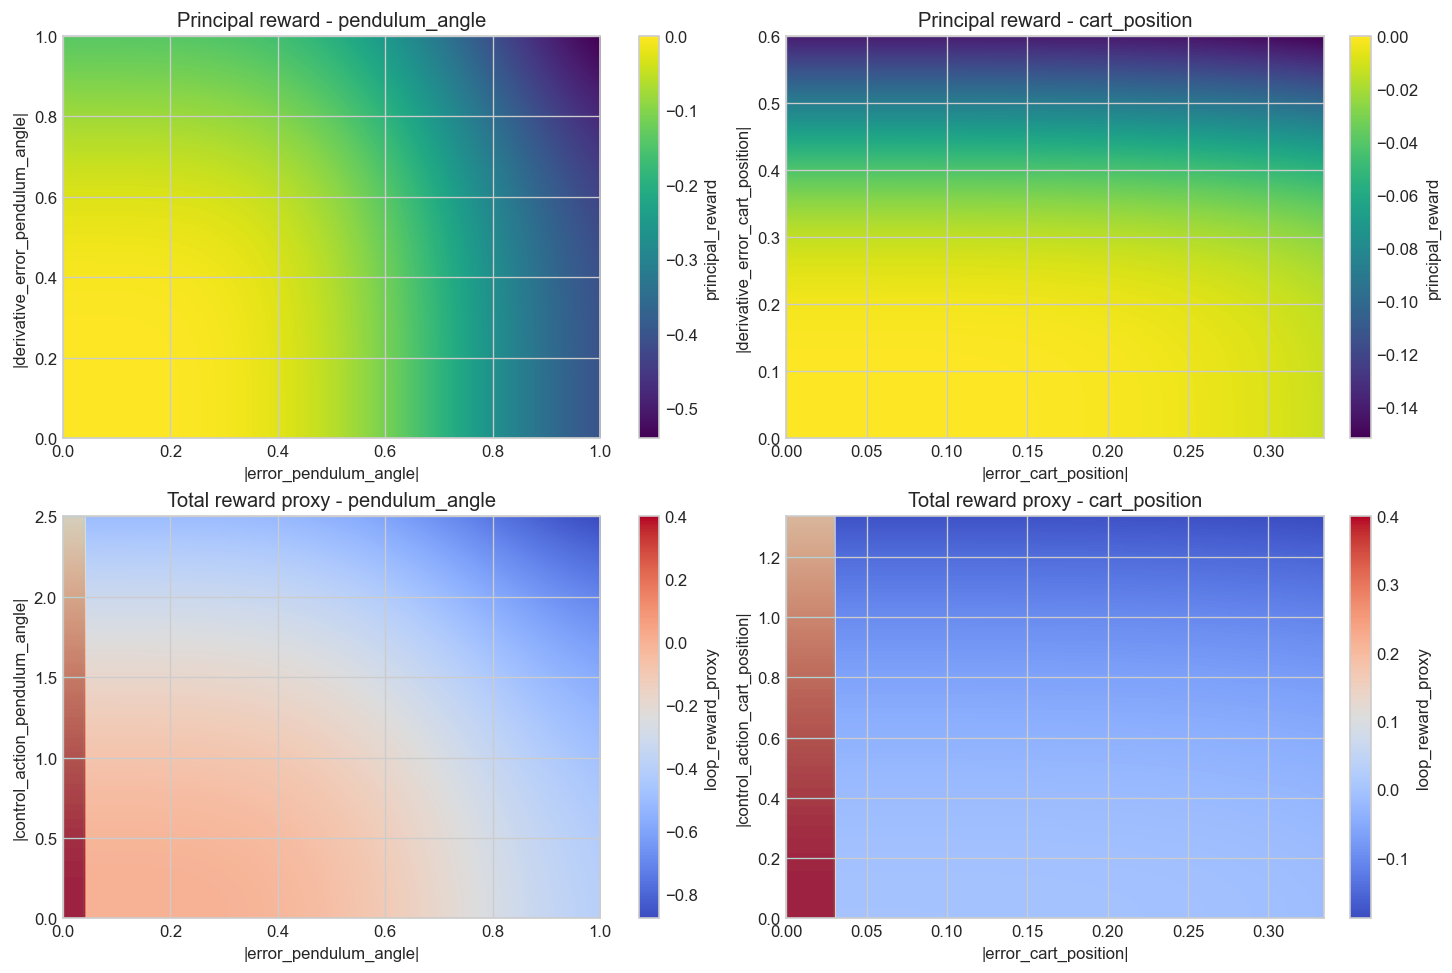

**Cómo interpretar estas superficies**

- La fila superior muestra la reward principal aislada en el espacio error-derivada, mientras que la fila inferior agrega bonus de banda y dynamic penalty para aproximar la reward total por lazo.
- Cuanto más favorable sea la región cercana al origen y a la franja sombreada, más alineado está el shaping con el objetivo de estabilización.
- Si la zona atractiva es demasiado pequeña o desaparece rápido al aumentar el control, la política puede recibir una señal demasiado exigente para aprender.
- Usa estas superficies para decidir si conviene retocar pesos, escalas, setpoints o bonus antes de mirar el comportamiento observado del agente.

In [40]:
section_name = "theoretical_surfaces"
section_cfg = SECTION_CONFIG[section_name]
require_items(section_cfg["target_vars"], section_name)
show_section_box("Superficies teóricas", section_cfg["box_df"])

target_vars = section_cfg["target_vars"]
fig, axes = plt.subplots(2, len(target_vars), figsize=(6 * len(target_vars), 8), constrained_layout=True)
if len(target_vars) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, var_obj in enumerate(target_vars):
    meta = VARIABLE_CATALOG[var_obj]
    error_col = meta["error_col"]
    derivative_col = meta["derivative_error_col"]
    control_col = meta["control_action_col"]

    error_max = observed_max(step_df[error_col], metric_range_abs(var_obj, ["e"], fallback=1.0))
    derivative_max = observed_max(step_df[derivative_col], metric_range_abs(var_obj, ["edot"], fallback=1.0))
    control_max = observed_max(step_df[control_col], metric_range_abs(var_obj, ["u", "delta_u"], fallback=1.0), floor=0.05)

    error_axis = np.linspace(0.0, error_max, 240)
    derivative_axis = np.linspace(0.0, derivative_max, 240)
    control_axis = np.linspace(0.0, control_max, 240)

    grid_error, grid_derivative = np.meshgrid(error_axis, derivative_axis)
    principal_surface = principal_loop_reward(var_obj, grid_error, grid_derivative)
    image_1 = axes[0, col].imshow(
        principal_surface,
        extent=[error_axis.min(), error_axis.max(), derivative_axis.min(), derivative_axis.max()],
        origin="lower",
        aspect="auto",
        cmap="viridis",
    )
    axes[0, col].set_title(f"Principal reward - {var_obj}")
    axes[0, col].set_xlabel(f"|{error_col}|")
    axes[0, col].set_ylabel(f"|{derivative_col}|")
    plt.colorbar(image_1, ax=axes[0, col], label="principal_reward")

    proxy_error, proxy_control = np.meshgrid(error_axis, control_axis)
    total_surface = total_proxy(var_obj, proxy_error, proxy_control, edot_level=0.0)
    image_2 = axes[1, col].imshow(
        total_surface,
        extent=[error_axis.min(), error_axis.max(), control_axis.min(), control_axis.max()],
        origin="lower",
        aspect="auto",
        cmap="coolwarm",
    )
    axes[1, col].set_title(f"Total reward proxy - {var_obj}")
    axes[1, col].set_xlabel(f"|{error_col}|")
    axes[1, col].set_ylabel(f"|{control_col}|")
    axes[1, col].axvspan(0.0, abs(band_range(var_obj)[1]), alpha=0.12, color="cyan")
    plt.colorbar(image_2, ax=axes[1, col], label="loop_reward_proxy")

plt.show()

show_note(
    "Cómo interpretar estas superficies",
    [
        "La fila superior muestra la reward principal aislada en el espacio error-derivada, mientras que la fila inferior agrega bonus de banda y dynamic penalty para aproximar la reward total por lazo.",
        "Cuanto más favorable sea la región cercana al origen y a la franja sombreada, más alineado está el shaping con el objetivo de estabilización.",
        "Si la zona atractiva es demasiado pequeña o desaparece rápido al aumentar el control, la política puede recibir una señal demasiado exigente para aprender.",
        "Usa estas superficies para decidir si conviene retocar pesos, escalas, setpoints o bonus antes de mirar el comportamiento observado del agente.",
    ],
)


## Cortes teóricos de reward

Estos perfiles convierten las superficies anteriores en curvas comparables para hacer más visible cómo cambia
la reward cuando fijamos distintos niveles de error o de esfuerzo de control.


**Caja de configuración — Cortes teóricos de reward**

,parameter_source,data_source,var_obj,x_error_col,x_control_col,error_profile_rule,control_profile_rule,band_range_raw
0,metadata + SECTION_TARGET_OVERRIDES,metadata + rangos observados del episodio,pendulum_angle,error_pendulum_angle,control_action_pendulum_angle,"0, 0.5*band, 1.0*band, min(observed_max, 2*band)","0, 15%, 35%, 65% del max observado","[-0.0400, 0.0400]"
1,metadata + SECTION_TARGET_OVERRIDES,metadata + rangos observados del episodio,cart_position,error_cart_position,control_action_cart_position,"0, 0.5*band, 1.0*band, min(observed_max, 2*band)","0, 15%, 35%, 65% del max observado","[-0.0300, 0.0300]"


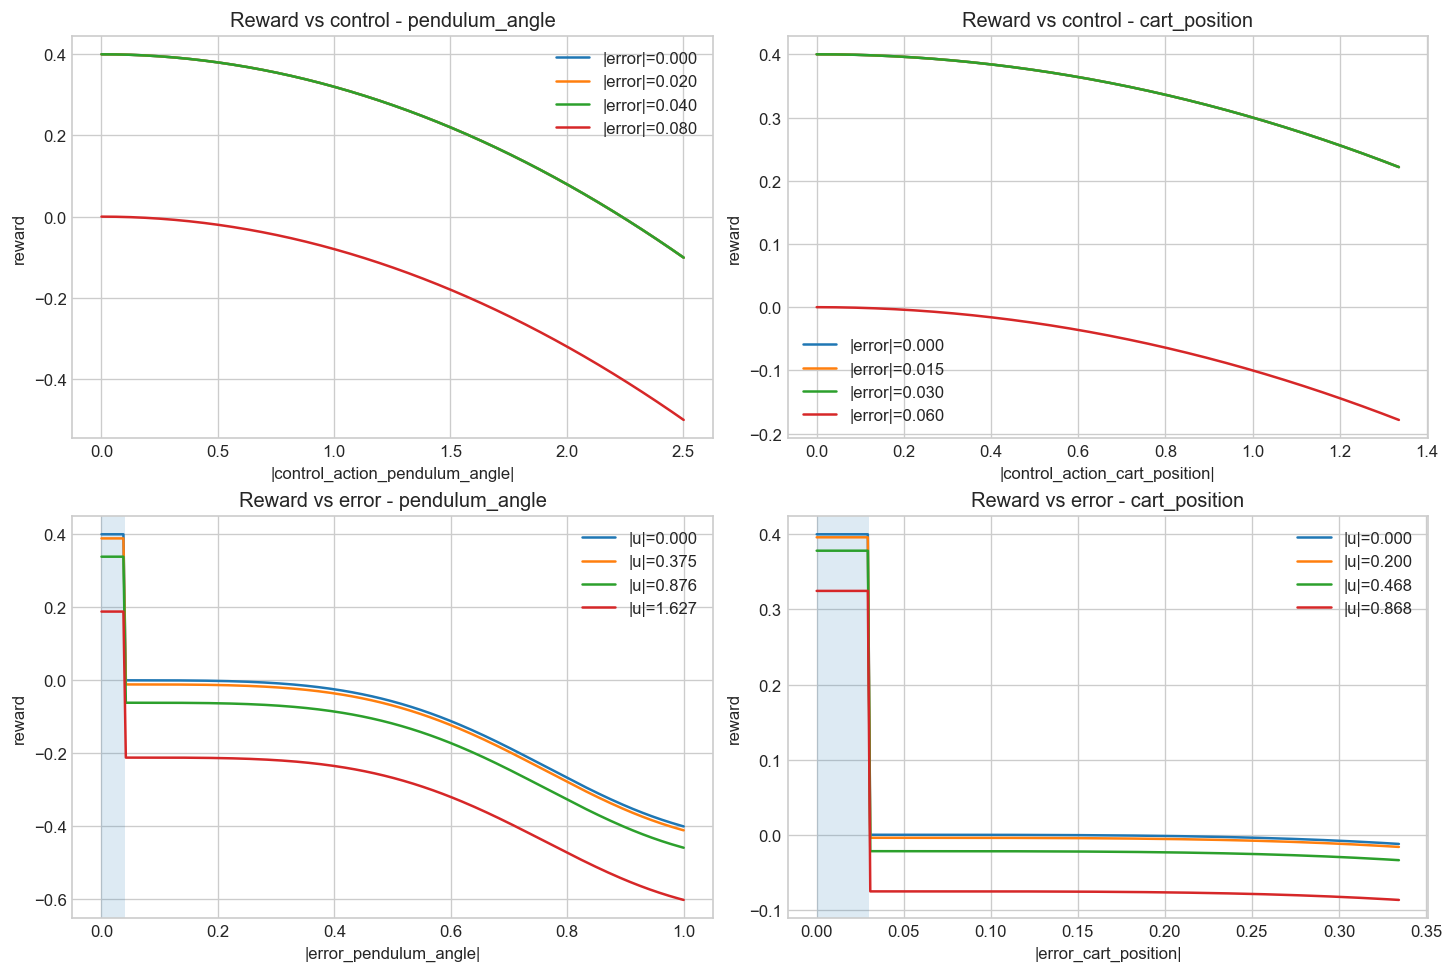

**Cómo usar estos cortes teóricos**

- La fila superior te dice cuánto castiga o tolera la reward distintas magnitudes de control cuando el error se mantiene fijo en varios niveles de referencia.
- La fila inferior muestra cómo cambia la reward frente al error cuando congelas distintos niveles de esfuerzo de control.
- Si la reward cae demasiado pronto dentro de la banda útil, probablemente el shaping esté penalizando de más y convenga suavizar pesos o penalties.
- Si fuera de banda la reward sigue siendo relativamente atractiva, suele ser señal de que hay que reforzar el peso del error o revisar la amplitud del bonus de banda.

In [41]:
section_name = "theoretical_profiles"
section_cfg = SECTION_CONFIG[section_name]
require_items(section_cfg["target_vars"], section_name)
show_section_box("Cortes teóricos de reward", section_cfg["box_df"])

target_vars = section_cfg["target_vars"]
fig, axes = plt.subplots(2, len(target_vars), figsize=(6 * len(target_vars), 8), constrained_layout=True)
if len(target_vars) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, var_obj in enumerate(target_vars):
    meta = VARIABLE_CATALOG[var_obj]
    error_col = meta["error_col"]
    control_col = meta["control_action_col"]

    error_max = observed_max(step_df[error_col], metric_range_abs(var_obj, ["e"], fallback=1.0))
    control_max = observed_max(step_df[control_col], metric_range_abs(var_obj, ["u", "delta_u"], fallback=1.0), floor=0.05)
    error_axis = np.linspace(0.0, error_max, 240)
    control_axis = np.linspace(0.0, control_max, 240)
    band_high = abs(band_range(var_obj)[1])

    error_levels = [0.0, 0.5 * band_high, band_high, min(error_max, 2.0 * band_high)]
    for error_level in error_levels:
        axes[0, col].plot(control_axis, total_proxy(var_obj, error_level, control_axis), label=f"|error|={error_level:.3f}")
    axes[0, col].set_title(f"Reward vs control - {var_obj}")
    axes[0, col].set_xlabel(f"|{control_col}|")
    axes[0, col].set_ylabel("reward")
    axes[0, col].legend()

    control_levels = [0.0, 0.15 * control_max, 0.35 * control_max, 0.65 * control_max]
    for control_level in control_levels:
        axes[1, col].plot(error_axis, total_proxy(var_obj, error_axis, control_level), label=f"|u|={control_level:.3f}")
    axes[1, col].axvspan(0.0, band_high, alpha=0.15)
    axes[1, col].set_title(f"Reward vs error - {var_obj}")
    axes[1, col].set_xlabel(f"|{error_col}|")
    axes[1, col].set_ylabel("reward")
    axes[1, col].legend()

plt.show()

show_note(
    "Cómo usar estos cortes teóricos",
    [
        "La fila superior te dice cuánto castiga o tolera la reward distintas magnitudes de control cuando el error se mantiene fijo en varios niveles de referencia.",
        "La fila inferior muestra cómo cambia la reward frente al error cuando congelas distintos niveles de esfuerzo de control.",
        "Si la reward cae demasiado pronto dentro de la banda útil, probablemente el shaping esté penalizando de más y convenga suavizar pesos o penalties.",
        "Si fuera de banda la reward sigue siendo relativamente atractiva, suele ser señal de que hay que reforzar el peso del error o revisar la amplitud del bonus de banda.",
    ],
)


## Curvas reales del episodio seleccionado

Aquí se reconstruye la descomposición real de reward del episodio elegido, para ver cómo se comportó la
señal de aprendizaje efectivamente usada durante la simulación.


**Caja de configuración — Curvas reales del episodio**

,parameter_source,data_source,var_obj,interval_axis,principal_col,extra_col,assigned_reward_col,rolling_window
0,metadata + SECTION_TARGET_OVERRIDES,episodio seleccionado,pendulum_angle,interval_id,principal_loop_pendulum_angle,extra_total_pendulum_angle,assigned_reward_pendulum_angle,15
1,metadata + SECTION_TARGET_OVERRIDES,episodio seleccionado,cart_position,interval_id,principal_loop_cart_position,extra_total_cart_position,assigned_reward_cart_position,15


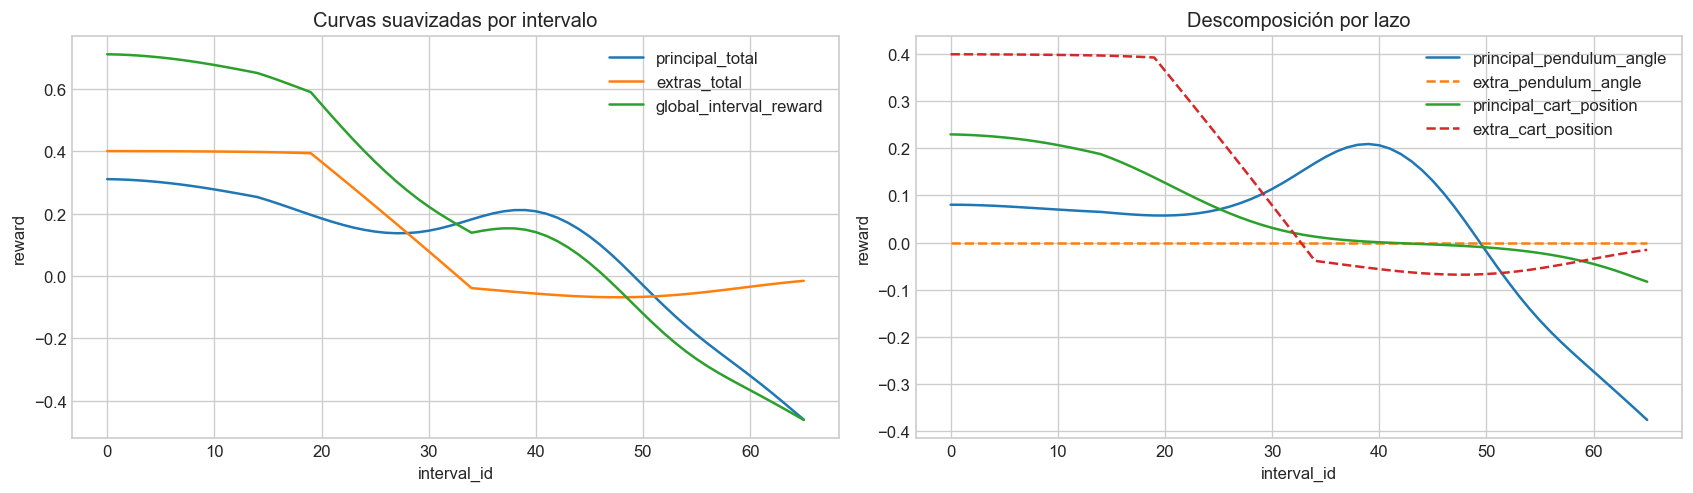

**Cómo analizar las curvas reales**

- La gráfica izquierda separa la contribución total principal, los extras y la reward global realmente observada en el episodio.
- La gráfica derecha baja la lectura al nivel de cada variable objetivo, lo que ayuda a detectar qué lazo depende más del shaping accesorio y cuál se sostiene principalmente con la reward base.
- Si los extras dominan de forma persistente, conviene revisar si están compensando una reward principal demasiado débil o mal escalada.
- Esta sección sirve para responder si el comportamiento observado está siendo guiado por el diseño central de reward o por ayudas temporales que luego podrían dificultar generalización.

,interval_id,global_interval_reward,principal_total_rebuilt,extras_total_rebuilt,principal_loop_pendulum_angle,extra_total_pendulum_angle,assigned_reward_pendulum_angle,principal_loop_cart_position,extra_total_cart_position,assigned_reward_cart_position
0,0.0,0.710196,0.310207,0.399989,0.080393,-2.219493e-07,0.080392,0.229814,0.399989,0.629803
1,1.0,0.708762,0.308837,0.399925,0.080133,-2.340799e-07,0.080133,0.228704,0.399926,0.628629
2,2.0,0.705156,0.305359,0.399797,0.078911,-2.344650e-07,0.078911,0.226448,0.399797,0.626245
3,3.0,0.699678,0.300074,0.399605,0.077027,-2.238496e-07,0.077026,0.223047,0.399605,0.622652
4,4.0,0.692439,0.293088,0.399353,0.074503,-2.040678e-07,0.074503,0.218584,0.399353,0.617937
5,5.0,0.683603,0.284561,0.399045,0.071402,-1.792534e-07,0.071401,0.213159,0.399045,0.612204
6,6.0,0.673204,0.274551,0.398658,0.068090,-1.779781e-07,0.068090,0.206460,0.398658,0.605119
7,7.0,0.661381,0.263203,0.398186,0.064737,-1.485191e-07,0.064737,0.198466,0.398187,0.596653
8,8.0,0.648169,0.250574,0.397610,0.061554,-1.396872e-07,0.061554,0.189020,0.397610,0.586630
9,9.0,0.633764,0.236864,0.396924,0.058605,-1.078620e-07,0.058605,0.178259,0.396925,0.575183


**Cómo usar la tabla del episodio**

- Cada fila resume un intervalo de decisión con su reward global y su reconstrucción por lazo.
- Comparar `principal_loop_*`, `extra_total_*` y `assigned_reward_*` ayuda a verificar si la asignación por variable es coherente con lo que muestran las curvas.
- Cuando una anomalía visual aparece en los gráficos, esta tabla es el lugar correcto para auditar intervalos concretos antes de cambiar pesos o reglas.
- Úsala como puente entre la intuición visual del notebook y la evidencia numérica del episodio seleccionado.

In [42]:
section_name = "interval_curves"
section_cfg = SECTION_CONFIG[section_name]
require_items(section_cfg["target_vars"], section_name)
show_section_box("Curvas reales del episodio", section_cfg["box_df"])

target_vars = section_cfg["target_vars"]
plot_df = behavior_df.copy()
plot_df["global_interval_reward_smooth"] = plot_df["global_interval_reward"].rolling(ROLLING_WINDOW, min_periods=1).mean()
plot_df["principal_total_smooth"] = plot_df["principal_total_rebuilt"].rolling(ROLLING_WINDOW, min_periods=1).mean()
plot_df["extras_total_smooth"] = plot_df["extras_total_rebuilt"].rolling(ROLLING_WINDOW, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axes[0].plot(plot_df["interval_id"], plot_df["principal_total_smooth"], label="principal_total")
axes[0].plot(plot_df["interval_id"], plot_df["extras_total_smooth"], label="extras_total")
axes[0].plot(plot_df["interval_id"], plot_df["global_interval_reward_smooth"], label="global_interval_reward")
axes[0].set_title("Curvas suavizadas por intervalo")
axes[0].set_xlabel("interval_id")
axes[0].set_ylabel("reward")
axes[0].legend()

for var_obj in target_vars:
    axes[1].plot(plot_df["interval_id"], plot_df[f"principal_loop_{var_obj}"].rolling(ROLLING_WINDOW, min_periods=1).mean(), label=f"principal_{var_obj}")
    axes[1].plot(plot_df["interval_id"], plot_df[f"extra_total_{var_obj}"].rolling(ROLLING_WINDOW, min_periods=1).mean(), linestyle="--", label=f"extra_{var_obj}")
axes[1].set_title("Descomposición por lazo")
axes[1].set_xlabel("interval_id")
axes[1].set_ylabel("reward")
axes[1].legend()
plt.show()

show_note(
    "Cómo analizar las curvas reales",
    [
        "La gráfica izquierda separa la contribución total principal, los extras y la reward global realmente observada en el episodio.",
        "La gráfica derecha baja la lectura al nivel de cada variable objetivo, lo que ayuda a detectar qué lazo depende más del shaping accesorio y cuál se sostiene principalmente con la reward base.",
        "Si los extras dominan de forma persistente, conviene revisar si están compensando una reward principal demasiado débil o mal escalada.",
        "Esta sección sirve para responder si el comportamiento observado está siendo guiado por el diseño central de reward o por ayudas temporales que luego podrían dificultar generalización.",
    ],
)

show_cols = ["interval_id", "global_interval_reward", "principal_total_rebuilt", "extras_total_rebuilt"]
for var_obj in target_vars:
    show_cols += [f"principal_loop_{var_obj}", f"extra_total_{var_obj}", f"assigned_reward_{var_obj}"]
display(behavior_df[show_cols].head(10))

show_note(
    "Cómo usar la tabla del episodio",
    [
        "Cada fila resume un intervalo de decisión con su reward global y su reconstrucción por lazo.",
        "Comparar `principal_loop_*`, `extra_total_*` y `assigned_reward_*` ayuda a verificar si la asignación por variable es coherente con lo que muestran las curvas.",
        "Cuando una anomalía visual aparece en los gráficos, esta tabla es el lugar correcto para auditar intervalos concretos antes de cambiar pesos o reglas.",
        "Úsala como puente entre la intuición visual del notebook y la evidencia numérica del episodio seleccionado.",
    ],
)


## Perfiles cruzados estilo notebook anterior

Esta sección conserva el espíritu del notebook previo: observar cómo cambia la reward total al recorrer una
variable física mientras condicionamos por distintos niveles de otra señal relevante.


**Caja de configuración — Perfiles cruzados**

,parameter_source,data_source,top_k,x_bins,min_curve_points,target_var,x_col,slice_var,slice_col,slice_label,reward_col,manual_slice_values
0,metadata + CROSS_PROFILE_MANUAL_SPECS + CROSS_...,best_stabilization_success_top_k,12,60,80,pendulum_angle,pendulum_angle_raw,cart_position,error_cart_position,e_x,global_reward_per_step,auto
1,metadata + CROSS_PROFILE_MANUAL_SPECS + CROSS_...,best_stabilization_success_top_k,12,60,80,cart_position,cart_position_raw,pendulum_angle,error_pendulum_angle,e_theta,global_reward_per_step,auto


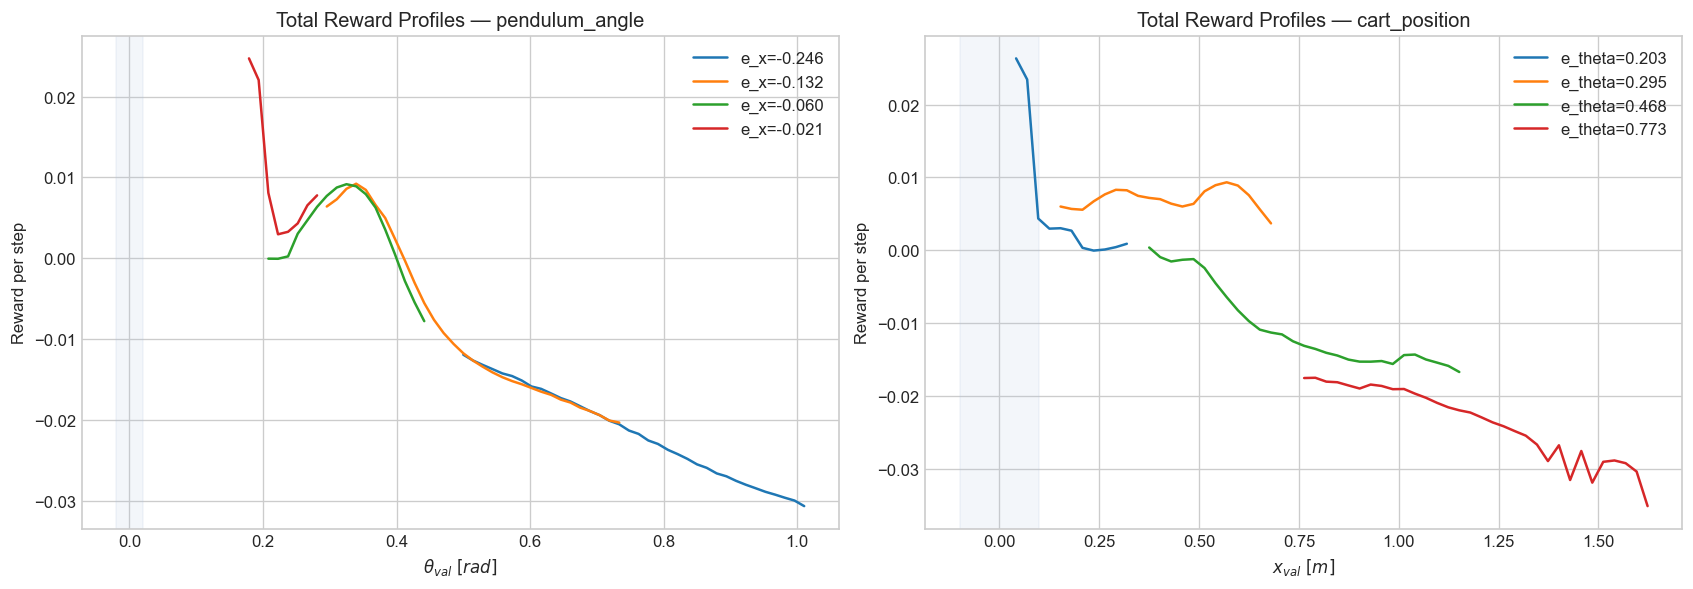

**Cómo leer estos perfiles cruzados**

- Cada curva muestra reward total por paso en función de la variable física del eje X, condicionada por distintos rangos de la variable indicada en `slice_col`.
- El cálculo usa varios episodios representativos cuando así se define en la caja de configuración, para evitar curvas engañosamente vacías o sesgadas por un único episodio.
- La franja sombreada marca la zona física de estabilización del estado analizado, por lo que el contraste entre curvas y banda ayuda a evaluar si la reward realmente favorece la operación deseada.
- Este gráfico es especialmente útil para decidir si una variable deja de ser atractiva demasiado pronto cuando otra señal aún está lejos de su objetivo.

**Soporte empírico — Total Reward Profiles — pendulum_angle**

,slice_label,slice_value,slice_low,slice_high,n_points,x_min,x_max
0,e_x,-0.246220,-0.355005,-0.183671,3119,0.501927,1.046965
1,e_x,-0.131585,-0.183671,-0.091104,3314,0.298370,0.737991
2,e_x,-0.060440,-0.091104,-0.037300,3278,0.209956,0.440040
3,e_x,-0.021090,-0.037300,-0.009919,3141,0.174649,0.275999
4,e_x,-0.002301,-0.009919,0.000000,3784,0.157000,0.192301


**Soporte empírico — Total Reward Profiles — cart_position**

,slice_label,slice_value,slice_low,slice_high,n_points,x_min,x_max
0,e_theta,0.156744,0.000000,0.175923,3709,0.000000,0.088339
1,e_theta,0.202661,0.175923,0.240708,3213,0.038382,0.323187
2,e_theta,0.294602,0.240708,0.368150,3311,0.147232,0.680936
3,e_theta,0.468458,0.368150,0.604401,3324,0.369417,1.155809
4,e_theta,0.773179,0.604401,0.997796,3079,0.761173,1.778718


**Cómo usar la tabla de soporte**

- La columna `n_points` indica cuánta evidencia real sostiene cada curva; una curva con poco soporte no debería usarse como argumento fuerte de tuning.
- Las columnas `slice_low` y `slice_high` muestran el rango efectivo de condicionamiento, lo que te permite verificar si el corte automático es razonable o si conviene fijar slices manuales.
- Los campos `x_min` y `x_max` ayudan a detectar cuándo una curva está bien soportada pero solo en una parte del dominio físico, algo importante al comparar carpetas distintas.
- Esta tabla convierte el gráfico en una herramienta auditable: no solo ves la forma de la curva, también sabes cuánta data real la respalda.

In [43]:
section_name = "cross_profiles"
section_cfg = SECTION_CONFIG[section_name]
require_items(section_cfg["specs"], section_name)
show_section_box("Perfiles cruzados", section_cfg["box_df"])

profile_specs = section_cfg["specs"]
fig, axes = plt.subplots(1, len(profile_specs), figsize=(7 * len(profile_specs), 4.8), constrained_layout=True)
if len(profile_specs) == 1:
    axes = [axes]

support_tables = {}
for ax, spec in zip(axes, profile_specs):
    support_tables[spec["title"]] = plot_cross_reward_profiles(
        ax=ax,
        df=cross_profile_df,
        x_col=spec["x_col"],
        slice_col=spec["slice_col"],
        reward_col=spec["reward_col"],
        target_var=spec["target_var"],
        slice_label=spec["slice_label"],
        title=spec["title"],
        x_label=spec["x_label"],
        slice_values=spec["slice_values"],
    )
plt.show()

show_note(
    "Cómo leer estos perfiles cruzados",
    [
        "Cada curva muestra reward total por paso en función de la variable física del eje X, condicionada por distintos rangos de la variable indicada en `slice_col`.",
        "El cálculo usa varios episodios representativos cuando así se define en la caja de configuración, para evitar curvas engañosamente vacías o sesgadas por un único episodio.",
        "La franja sombreada marca la zona física de estabilización del estado analizado, por lo que el contraste entre curvas y banda ayuda a evaluar si la reward realmente favorece la operación deseada.",
        "Este gráfico es especialmente útil para decidir si una variable deja de ser atractiva demasiado pronto cuando otra señal aún está lejos de su objetivo.",
    ],
)

for title, table in support_tables.items():
    display(Markdown(f"**Soporte empírico — {title}**"))
    display(table)

show_note(
    "Cómo usar la tabla de soporte",
    [
        "La columna `n_points` indica cuánta evidencia real sostiene cada curva; una curva con poco soporte no debería usarse como argumento fuerte de tuning.",
        "Las columnas `slice_low` y `slice_high` muestran el rango efectivo de condicionamiento, lo que te permite verificar si el corte automático es razonable o si conviene fijar slices manuales.",
        "Los campos `x_min` y `x_max` ayudan a detectar cuándo una curva está bien soportada pero solo en una parte del dominio físico, algo importante al comparar carpetas distintas.",
        "Esta tabla convierte el gráfico en una herramienta auditable: no solo ves la forma de la curva, también sabes cuánta data real la respalda.",
    ],
)


## Perfiles empíricos de reward

Aquí se observa cómo cambia la reward media asignada cuando el sistema visita distintos niveles de error y de
esfuerzo de control a nivel de intervalo.


**Caja de configuración — Perfiles empíricos de reward**

,parameter_source,data_source,var_obj,x_error_col,x_control_col,principal_col,extra_col,assigned_reward_col
0,metadata + SECTION_TARGET_OVERRIDES,episodio seleccionado,pendulum_angle,mean_abs_error_pendulum_angle,mean_abs_control_action_pendulum_angle,principal_loop_pendulum_angle,extra_total_pendulum_angle,assigned_reward_pendulum_angle
1,metadata + SECTION_TARGET_OVERRIDES,episodio seleccionado,cart_position,mean_abs_error_cart_position,mean_abs_control_action_cart_position,principal_loop_cart_position,extra_total_cart_position,assigned_reward_cart_position


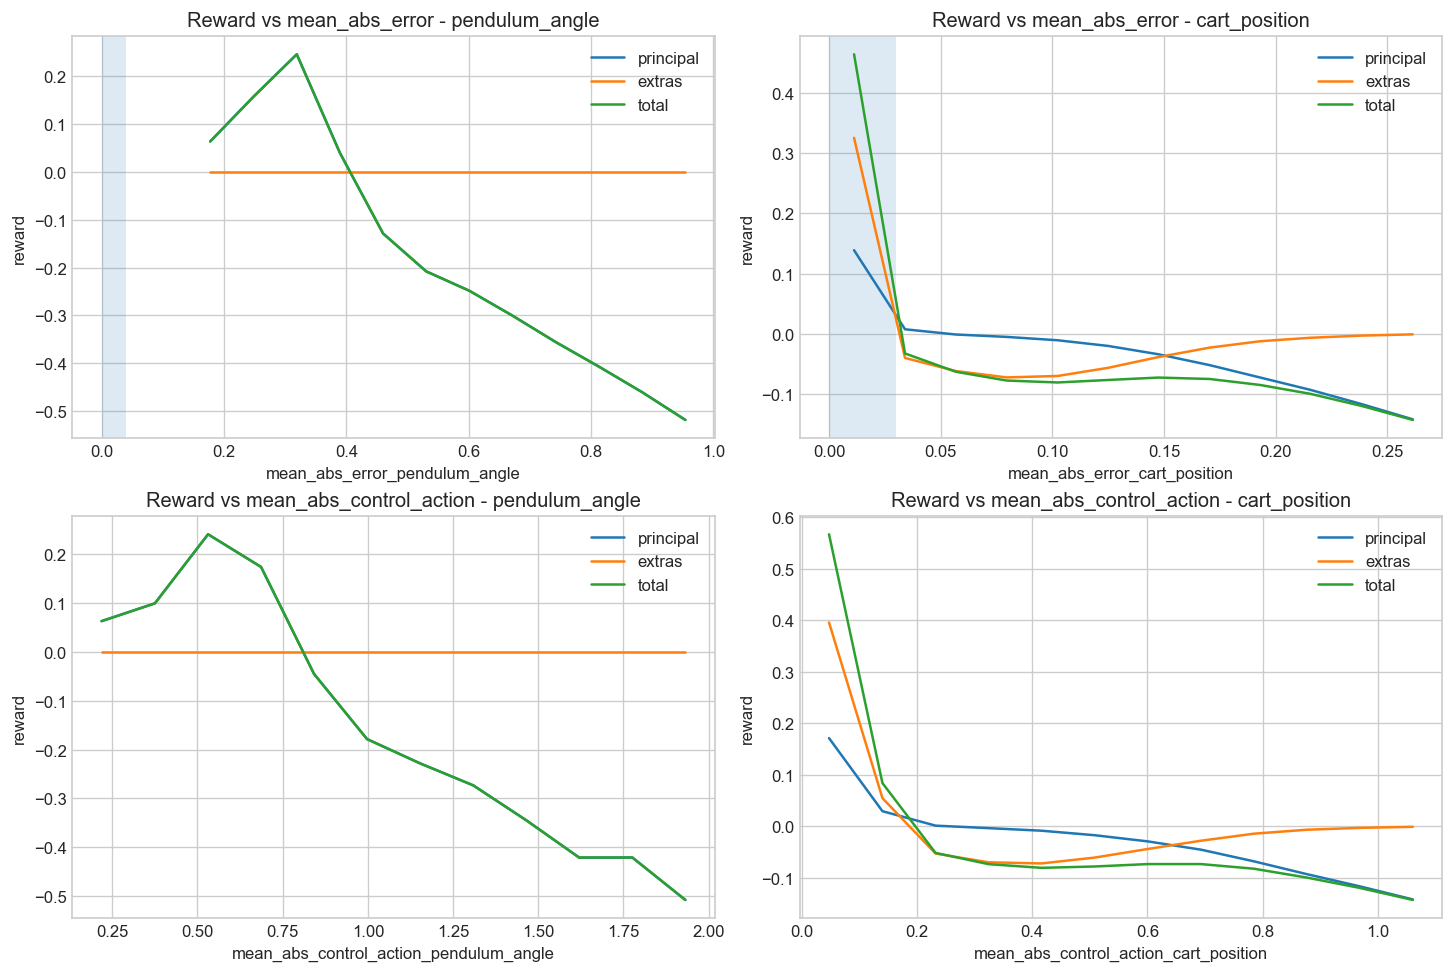

**Cómo interpretar los perfiles empíricos**

- Estos perfiles muestran cómo responde la reward media a lo que la política realmente visitó, no solo a lo que el diseño teórico permitiría.
- La comparación entre principal, extras y total ayuda a detectar si la forma observada del aprendizaje coincide o no con la intuición del diseño original.
- Si la curva total mejora solo por aportes extra y la principal sigue siendo débil, probablemente el sistema esté aprendiendo con una señal base poco informativa.
- Esta sección sirve para decidir si el siguiente ajuste debe hacerse en la reward base, en los extras o en ambos al mismo tiempo.

In [44]:
section_name = "empirical_profiles"
section_cfg = SECTION_CONFIG[section_name]
require_items(section_cfg["target_vars"], section_name)
show_section_box("Perfiles empíricos de reward", section_cfg["box_df"])

target_vars = section_cfg["target_vars"]
fig, axes = plt.subplots(2, len(target_vars), figsize=(6 * len(target_vars), 8), constrained_layout=True)
if len(target_vars) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, var_obj in enumerate(target_vars):
    error_profile = profile(
        behavior_df,
        f"mean_abs_error_{var_obj}",
        [f"principal_loop_{var_obj}", f"extra_total_{var_obj}", f"assigned_reward_{var_obj}"],
    )
    axes[0, col].plot(error_profile[f"mean_abs_error_{var_obj}"], error_profile[f"principal_loop_{var_obj}"], label="principal")
    axes[0, col].plot(error_profile[f"mean_abs_error_{var_obj}"], error_profile[f"extra_total_{var_obj}"], label="extras")
    axes[0, col].plot(error_profile[f"mean_abs_error_{var_obj}"], error_profile[f"assigned_reward_{var_obj}"], label="total")
    axes[0, col].axvspan(0.0, abs(band_range(var_obj)[1]), alpha=0.15)
    axes[0, col].set_title(f"Reward vs mean_abs_error - {var_obj}")
    axes[0, col].set_xlabel(f"mean_abs_error_{var_obj}")
    axes[0, col].set_ylabel("reward")
    axes[0, col].legend()

    control_profile = profile(
        behavior_df,
        f"mean_abs_control_action_{var_obj}",
        [f"principal_loop_{var_obj}", f"extra_total_{var_obj}", f"assigned_reward_{var_obj}"],
    )
    axes[1, col].plot(control_profile[f"mean_abs_control_action_{var_obj}"], control_profile[f"principal_loop_{var_obj}"], label="principal")
    axes[1, col].plot(control_profile[f"mean_abs_control_action_{var_obj}"], control_profile[f"extra_total_{var_obj}"], label="extras")
    axes[1, col].plot(control_profile[f"mean_abs_control_action_{var_obj}"], control_profile[f"assigned_reward_{var_obj}"], label="total")
    axes[1, col].set_title(f"Reward vs mean_abs_control_action - {var_obj}")
    axes[1, col].set_xlabel(f"mean_abs_control_action_{var_obj}")
    axes[1, col].set_ylabel("reward")
    axes[1, col].legend()

plt.show()

show_note(
    "Cómo interpretar los perfiles empíricos",
    [
        "Estos perfiles muestran cómo responde la reward media a lo que la política realmente visitó, no solo a lo que el diseño teórico permitiría.",
        "La comparación entre principal, extras y total ayuda a detectar si la forma observada del aprendizaje coincide o no con la intuición del diseño original.",
        "Si la curva total mejora solo por aportes extra y la principal sigue siendo débil, probablemente el sistema esté aprendiendo con una señal base poco informativa.",
        "Esta sección sirve para decidir si el siguiente ajuste debe hacerse en la reward base, en los extras o en ambos al mismo tiempo.",
    ],
)


## Densidad step-level en el espacio error-control

Este mapa muestra dónde pasa realmente el sistema la mayor parte del tiempo durante el episodio seleccionado.


**Caja de configuración — Densidad step-level**

,parameter_source,data_source,var_obj,x_col,y_col,highlight_band
0,metadata + SECTION_TARGET_OVERRIDES,step_data del episodio seleccionado,pendulum_angle,error_pendulum_angle,control_action_pendulum_angle,"[-0.0400, 0.0400]"
1,metadata + SECTION_TARGET_OVERRIDES,step_data del episodio seleccionado,cart_position,error_cart_position,control_action_cart_position,"[-0.0300, 0.0300]"


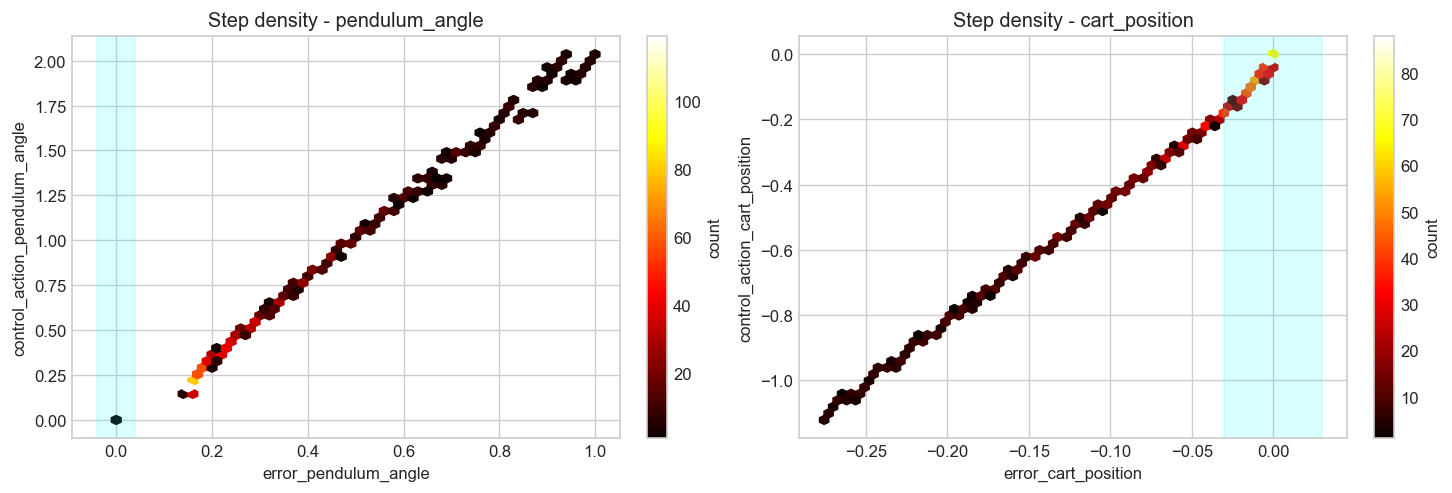

**Cómo analizar la densidad step-level**

- El mapa indica qué combinaciones de error y control fueron realmente visitadas con más frecuencia por el sistema durante el episodio.
- Comparar la nube densa con la banda sombreada permite ver si la política opera donde la reward intenta concentrar el comportamiento deseado o si permanece lejos de esa zona.
- Si la mayor densidad está fuera de la banda y además requiere alto esfuerzo de control, suele ser una señal de que la política está luchando contra una geometría de reward poco favorable.
- Úsalo para decidir si reforzar bonus de banda, suavizar penalties o revisar la autoridad y saturación del controlador.

In [45]:
section_name = "step_density_maps"
section_cfg = SECTION_CONFIG[section_name]
require_items(section_cfg["target_vars"], section_name)
show_section_box("Densidad step-level", section_cfg["box_df"])

target_vars = section_cfg["target_vars"]
fig, axes = plt.subplots(1, len(target_vars), figsize=(6 * len(target_vars), 4), constrained_layout=True)
if len(target_vars) == 1:
    axes = [axes]

for ax, var_obj in zip(axes, target_vars):
    meta = VARIABLE_CATALOG[var_obj]
    heatmap = ax.hexbin(step_df[meta["error_col"]], step_df[meta["control_action_col"]], gridsize=50, cmap="hot", mincnt=1)
    band_low, band_high = band_range(var_obj)
    ax.axvspan(band_low, band_high, alpha=0.15, color="cyan")
    ax.set_title(f"Step density - {var_obj}")
    ax.set_xlabel(meta["error_col"])
    ax.set_ylabel(meta["control_action_col"])
    plt.colorbar(heatmap, ax=ax, label="count")

plt.show()

show_note(
    "Cómo analizar la densidad step-level",
    [
        "El mapa indica qué combinaciones de error y control fueron realmente visitadas con más frecuencia por el sistema durante el episodio.",
        "Comparar la nube densa con la banda sombreada permite ver si la política opera donde la reward intenta concentrar el comportamiento deseado o si permanece lejos de esa zona.",
        "Si la mayor densidad está fuera de la banda y además requiere alto esfuerzo de control, suele ser una señal de que la política está luchando contra una geometría de reward poco favorable.",
        "Úsalo para decidir si reforzar bonus de banda, suavizar penalties o revisar la autoridad y saturación del controlador.",
    ],
)


## Mapa interval-level de comportamiento y reward

Esta figura combina ocupación observada y señal de reward a nivel de intervalo, lo que la vuelve muy útil
para decisiones de sintonización más integradas.


**Caja de configuración — Mapa interval-level**

,parameter_source,data_source,var_obj,x_col,y_col,color_col,highlight_band
0,metadata + SECTION_TARGET_OVERRIDES,interval_data reconstruido,pendulum_angle,mean_abs_error_pendulum_angle,mean_abs_control_action_pendulum_angle,assigned_reward_pendulum_angle,"[-0.0400, 0.0400]"
1,metadata + SECTION_TARGET_OVERRIDES,interval_data reconstruido,cart_position,mean_abs_error_cart_position,mean_abs_control_action_cart_position,assigned_reward_cart_position,"[-0.0300, 0.0300]"


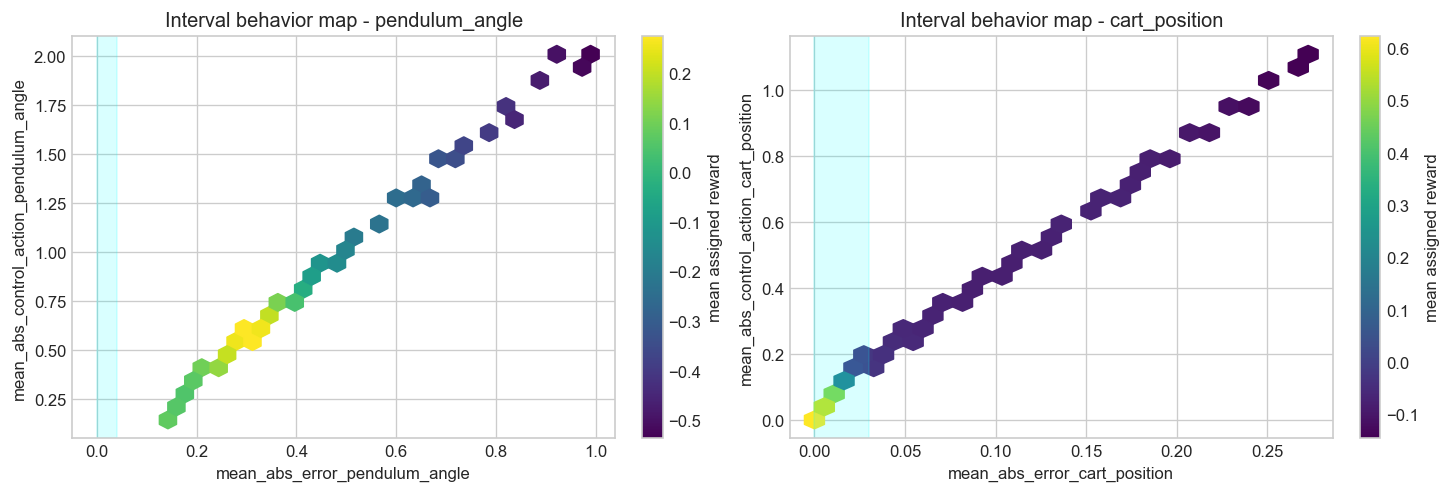

**Cómo usar el mapa interval-level**

- Cada hexágono resume combinaciones observadas de error medio y esfuerzo medio, coloreadas por la reward media asignada en esos intervalos.
- Esta vista permite distinguir entre regiones que el sistema visita mucho pero premia poco, y regiones menos frecuentes pero claramente favorecidas por el shaping actual.
- Las zonas densas con reward baja suelen ser el mejor punto de partida para rediseñar pesos o extras, porque allí se concentra experiencia real con señal poco útil.
- Es una figura ideal para cerrar el análisis: combina distribución de comportamiento, severidad del control y calidad de la señal de aprendizaje en una misma lectura.

In [46]:
section_name = "interval_behavior_maps"
section_cfg = SECTION_CONFIG[section_name]
require_items(section_cfg["target_vars"], section_name)
show_section_box("Mapa interval-level", section_cfg["box_df"])

target_vars = section_cfg["target_vars"]
fig, axes = plt.subplots(1, len(target_vars), figsize=(6 * len(target_vars), 4), constrained_layout=True)
if len(target_vars) == 1:
    axes = [axes]

for ax, var_obj in zip(axes, target_vars):
    heatmap = ax.hexbin(
        behavior_df[f"mean_abs_error_{var_obj}"],
        behavior_df[f"mean_abs_control_action_{var_obj}"],
        C=behavior_df[f"assigned_reward_{var_obj}"],
        reduce_C_function=np.mean,
        gridsize=25,
        cmap="viridis",
        mincnt=1,
    )
    ax.axvspan(0.0, abs(band_range(var_obj)[1]), alpha=0.15, color="cyan")
    ax.set_title(f"Interval behavior map - {var_obj}")
    ax.set_xlabel(f"mean_abs_error_{var_obj}")
    ax.set_ylabel(f"mean_abs_control_action_{var_obj}")
    plt.colorbar(heatmap, ax=ax, label="mean assigned reward")

plt.show()

show_note(
    "Cómo usar el mapa interval-level",
    [
        "Cada hexágono resume combinaciones observadas de error medio y esfuerzo medio, coloreadas por la reward media asignada en esos intervalos.",
        "Esta vista permite distinguir entre regiones que el sistema visita mucho pero premia poco, y regiones menos frecuentes pero claramente favorecidas por el shaping actual.",
        "Las zonas densas con reward baja suelen ser el mejor punto de partida para rediseñar pesos o extras, porque allí se concentra experiencia real con señal poco útil.",
        "Es una figura ideal para cerrar el análisis: combina distribución de comportamiento, severidad del control y calidad de la señal de aprendizaje en una misma lectura.",
    ],
)
